In [27]:
import pandas as pd
import numpy as np
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# models you want to use
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# regression versions
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

### Project Goal

This project tries to reproduce a common claim made in studies using the Wine Quality dataset. The main claim is that wine quality can be predicted from physicochemical features, that Random Forest usually performs better than simpler models, and that variables like alcohol are among the strongest predictors.

To test this, I used both regression and classification approaches. I also changed the quality threshold later in the analysis to see how much the results depend on how the problem is defined.

### CLASS IMBALANCE FOR ALL WINE TYPE

In [4]:
red = pd.read_csv(("winequality-red.csv"), sep=";")
white = pd.read_csv(("winequality-white.csv"), sep=";")

In [6]:
red.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [7]:
white.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [8]:
# check for duplicates and nan values
print("red wine")
print(red.duplicated().sum())
print(red.isnull().sum())
print("\nwhite wine")
print(white.duplicated().sum())
print(white.isnull().sum())


red wine
240
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

white wine
937
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


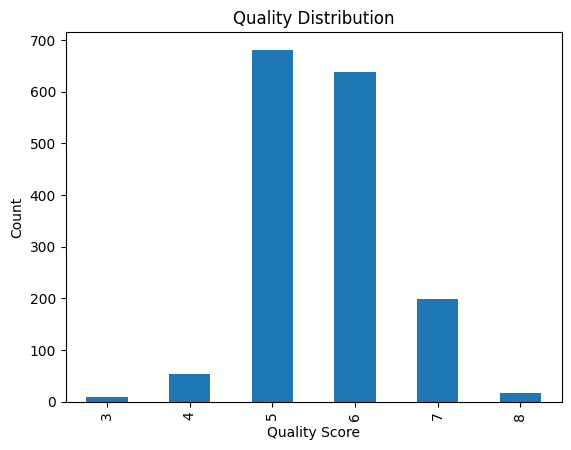

In [9]:
# Class imbalance for Red Wine
red["quality"].value_counts().sort_index().plot(kind="bar")
plt.title("Quality Distribution")
plt.xlabel("Quality Score")
plt.ylabel("Count")
plt.show()

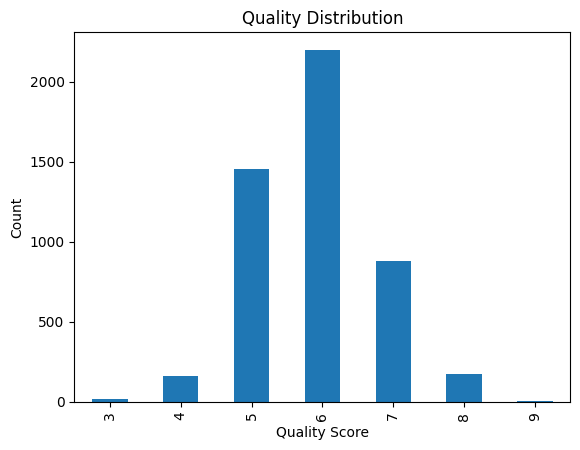

In [10]:
# Class Imbalance for White Wine
white["quality"].value_counts().sort_index().plot(kind="bar")
plt.title("Quality Distribution")
plt.xlabel("Quality Score")
plt.ylabel("Count")
plt.show()

### CORRELATION HEATMAPS

In [11]:
# Correlation heatmap for each wine
corr_red = red.corr()
corr_white = white.corr()


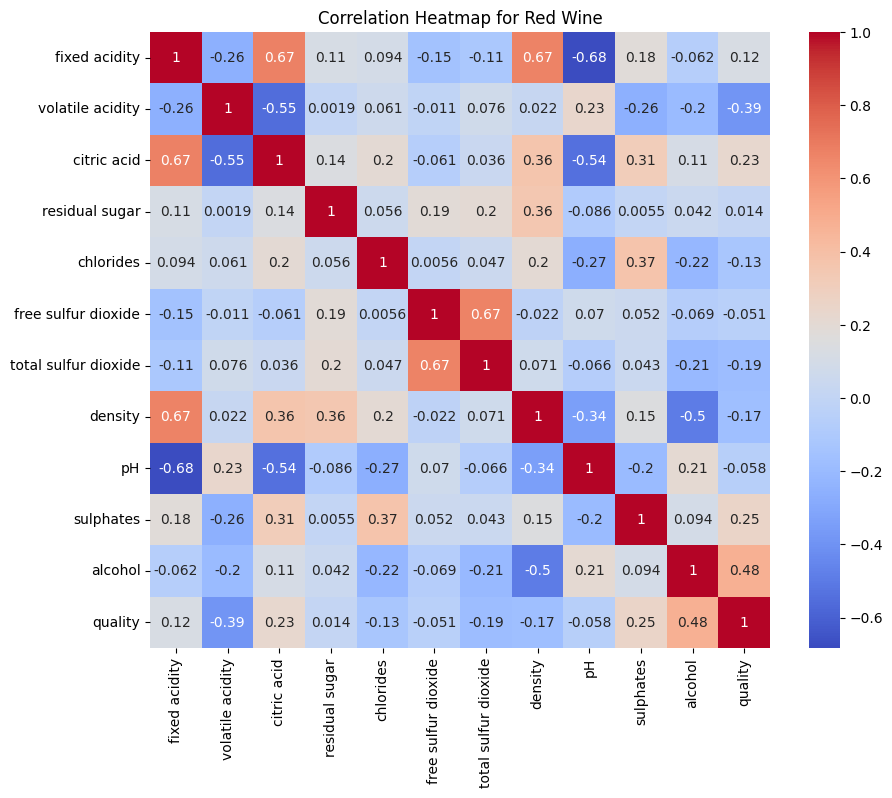

In [12]:
# display correlation heatmap for red wine
plt.figure(figsize=(10, 8))
sns.heatmap(corr_red, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap for Red Wine")
plt.show()

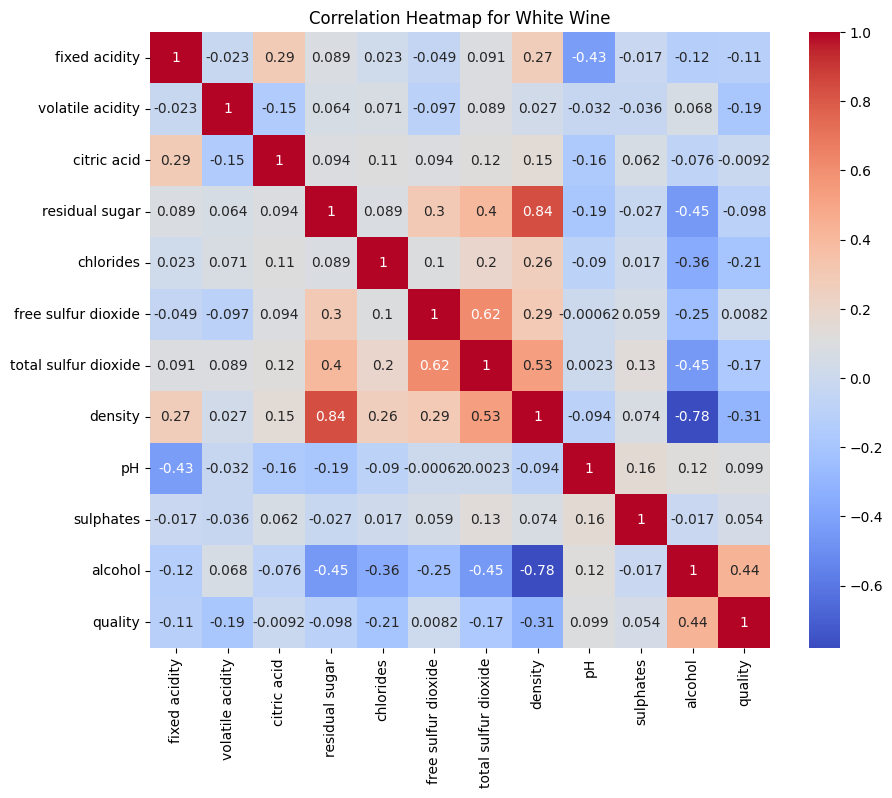

In [13]:
# display heatmap for white wine
plt.figure(figsize=(10, 8))
sns.heatmap(corr_white, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap for White Wine")
plt.show()

In [14]:
#Display correlation with quality and show chart
corr_red["quality"].sort_values(ascending=False)


,quality
quality,1.000000
alcohol,0.476166
sulphates,0.251397
citric acid,0.226373
fixed acidity,0.124052
residual sugar,0.013732
free sulfur dioxide,-0.050656
pH,-0.057731
chlorides,-0.128907
density,-0.174919


In [15]:
# wine feature importance
corr_white["quality"].sort_values(ascending=False)


,quality
quality,1.000000
alcohol,0.435575
pH,0.099427
sulphates,0.053678
free sulfur dioxide,0.008158
citric acid,-0.009209
residual sugar,-0.097577
fixed acidity,-0.113663
total sulfur dioxide,-0.174737
volatile acidity,-0.194723


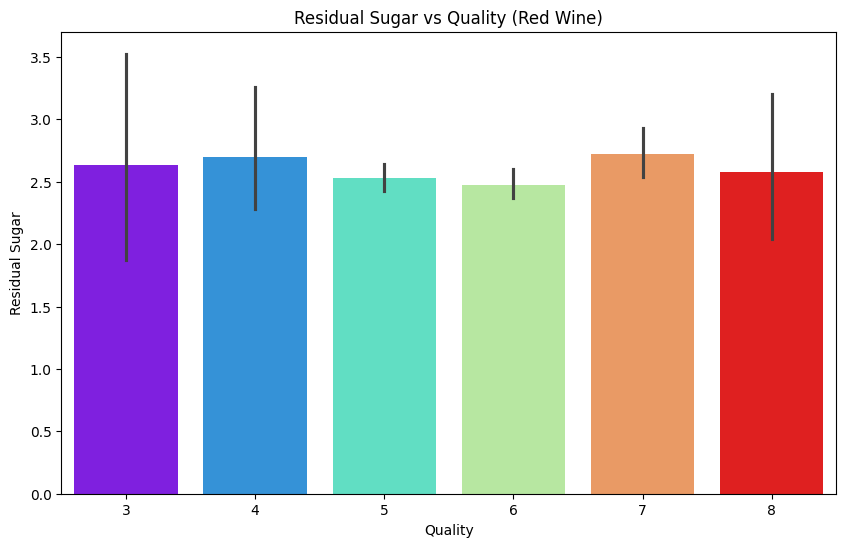

In [20]:
# bar chart for residual sugar versus quality
plt.figure(figsize=(10, 6))
sns.barplot(x="quality", y="residual sugar", data=red, palette="rainbow", hue="quality", legend=False)
plt.title("Residual Sugar vs Quality (Red Wine)")
plt.xlabel("Quality")
plt.ylabel("Residual Sugar")
plt.show()

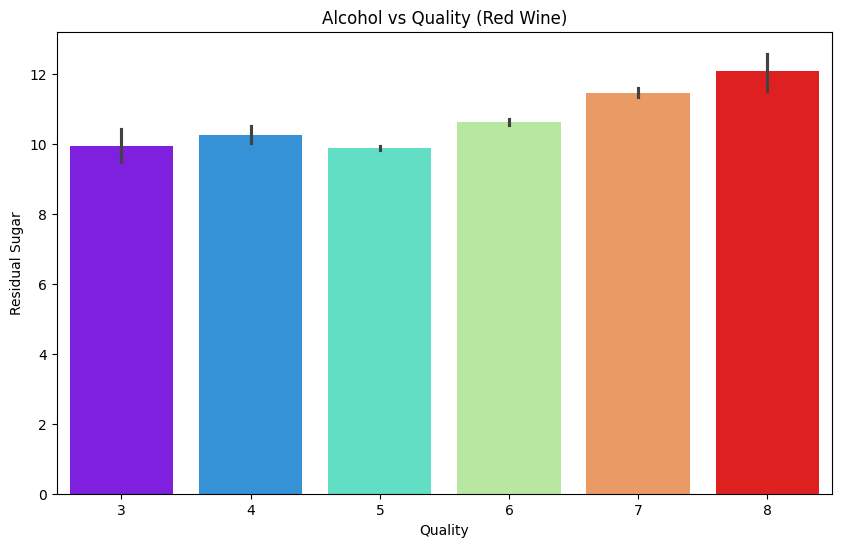

In [24]:
# bar chart for residual sugar versus quality
plt.figure(figsize=(10, 6))
sns.barplot(x="quality", y="alcohol", data=red, palette="rainbow", hue="quality", legend=False)
plt.title("Alcohol vs Quality (Red Wine)")
plt.xlabel("Quality")
plt.ylabel("Residual Sugar")
plt.show()

#### Combining both datasets

In [25]:

red["type"] = 0
white["type"] = 1

df = pd.concat([red, white], axis=0)

print(df.shape)
df.head()


['winequality-red.csv', 'winequality-white.csv', 'winequality.names']
(6497, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


In [41]:
print("shape before dropping duplicates:", df.shape)
print("\nmissing values:")
print(df.isnull().sum())

print("\nduplicates:", df.duplicated().sum())
print("\ndata types:")
print(df.dtypes)

shape before dropping duplicates: (6497, 13)

missing values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64

duplicates: 1177

data types:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
type                      int64
dtype: object


In [43]:
df = df.drop_duplicates()
df.shape

(5320, 13)

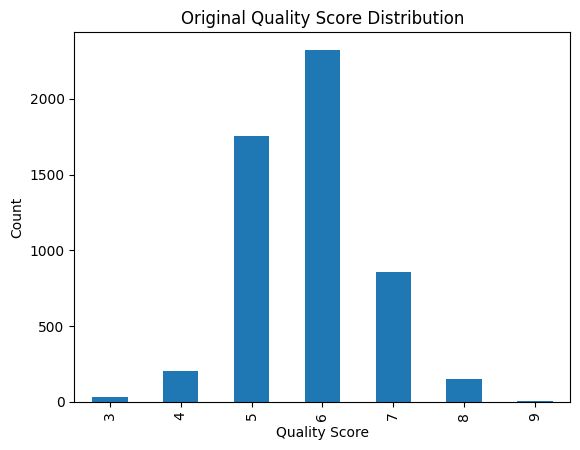

In [44]:
df["quality"].value_counts().sort_index().plot(kind="bar")
plt.title("Original Quality Score Distribution")
plt.xlabel("Quality Score")
plt.ylabel("Count")
plt.show()

In [45]:
def quality_group(q):
    if q < 5:
        return 0
    elif 5 <= q <= 6:
        return 1
    else:
        return 2

df["quality_class"] = df["quality"].apply(quality_group)

print(df["quality_class"].value_counts().sort_index())

quality_class
0     236
1    4075
2    1009
Name: count, dtype: int64


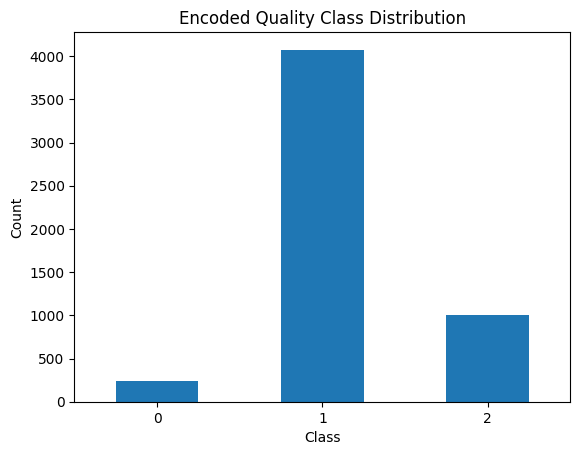

In [47]:
df["quality_class"].value_counts().sort_index().plot(kind="bar")
plt.title("Encoded Quality Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

### Class Meaning

Class 0 represents bad wine.  
Class 1 represents normal wine.  
Class 2 represents good wine.

This follows the label encoding shown in the paper and changes the problem from binary classification to multi class classification.

In [48]:
X = df.drop(columns=["quality", "quality_class"])
y = df["quality_class"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nclass counts:")
print(y.value_counts().sort_index())

X shape: (5320, 12)
y shape: (5320,)

class counts:
quality_class
0     236
1    4075
2    1009
Name: count, dtype: int64


In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (4256, 12)
X_test shape: (1064, 12)


In [52]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Unbalanced Dataset

This version keeps the original class distribution from the wine dataset. Since some classes appear more often than others, this is considered the unbalanced dataset. This matches the paper's first setup.

In [53]:
models_unbalanced = {
    "SVM": SVC(),
    "RF": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(),
    "GB": GradientBoostingClassifier(random_state=42),
    "DT": DecisionTreeClassifier(random_state=42)
}

results_unbalanced = []

for name, model in models_unbalanced.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)

    report = classification_report(y_test, preds, output_dict=True)

    results_unbalanced.append([
        name,
        report["0"]["precision"], report["0"]["recall"], report["0"]["f1-score"],
        report["1"]["precision"], report["1"]["recall"], report["1"]["f1-score"],
        report["2"]["precision"], report["2"]["recall"], report["2"]["f1-score"],
        accuracy_score(y_test, preds)
    ])

unbalanced_table = pd.DataFrame(
    results_unbalanced,
    columns=[
        "Model",
        "Class0_Precision", "Class0_Recall", "Class0_F1",
        "Class1_Precision", "Class1_Recall", "Class1_F1",
        "Class2_Precision", "Class2_Recall", "Class2_F1",
        "Accuracy"
    ]
)

print("Unbalanced Dataset Results")
unbalanced_table

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Unbalanced Dataset Results


,Model,Class0_Precision,Class0_Recall,Class0_F1,Class1_Precision,Class1_Recall,Class1_F1,Class2_Precision,Class2_Recall,Class2_F1,Accuracy
0,SVM,0.000000,0.000000,0.000000,0.803662,0.969325,0.878754,0.679012,0.272277,0.388693,0.794173
1,RF,0.200000,0.021277,0.038462,0.816456,0.949693,0.878049,0.657658,0.361386,0.466454,0.796992
2,KNN,0.333333,0.085106,0.135593,0.820287,0.912883,0.864111,0.558621,0.400990,0.466859,0.779135
3,GB,0.400000,0.127660,0.193548,0.810235,0.932515,0.867085,0.576577,0.316832,0.408946,0.780075
4,DT,0.160714,0.191489,0.174757,0.802484,0.792638,0.797531,0.364532,0.366337,0.365432,0.685150


In [54]:
# Transpose models
unbalanced_table_t = unbalanced_table.set_index("Model").T
unbalanced_table_t

Model,SVM,RF,KNN,GB,DT
Class0_Precision,0.000000,0.200000,0.333333,0.400000,0.160714
Class0_Recall,0.000000,0.021277,0.085106,0.127660,0.191489
Class0_F1,0.000000,0.038462,0.135593,0.193548,0.174757
Class1_Precision,0.803662,0.816456,0.820287,0.810235,0.802484
Class1_Recall,0.969325,0.949693,0.912883,0.932515,0.792638
Class1_F1,0.878754,0.878049,0.864111,0.867085,0.797531
Class2_Precision,0.679012,0.657658,0.558621,0.576577,0.364532
Class2_Recall,0.272277,0.361386,0.400990,0.316832,0.366337
Class2_F1,0.388693,0.466454,0.466859,0.408946,0.365432
Accuracy,0.794173,0.796992,0.779135,0.780075,0.685150


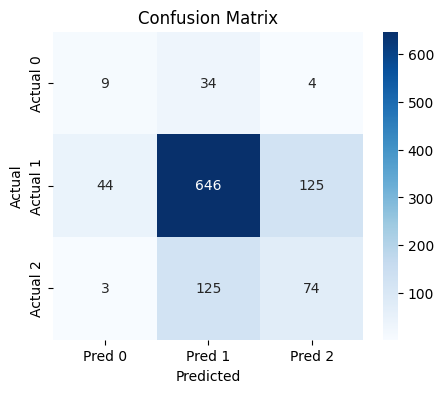

In [56]:
# confusion matrix for unbalanced dataset and plot
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred 0", "Pred 1", "Pred 2"],
    yticklabels=["Actual 0", "Actual 1", "Actual 2"]
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### What the unbalanced results show


The results from the unbalanced dataset show that the models perform unevenly across the three classes. This is expected because the dataset contains far fewer samples for class 0 and class 2 compared to class 1.

Looking at the confusion matrix, most predictions are concentrated in class 1. For example, out of all actual class 1 wines, 646 were correctly predicted, which explains the very high recall of about 0.96 for that class. This means the models are very good at identifying normal wines.

However, performance drops significantly for the other classes. For class 0, the recall is extremely low across all models. In the confusion matrix, only 9 samples were correctly classified as class 0, while most were incorrectly predicted as class 1. This shows that the models are struggling to detect bad wines at all.

A similar pattern appears for class 2. While precision is moderate, recall is still relatively low. For example, 74 samples were correctly predicted as class 2, but many were misclassified as class 1. This indicates that good wines are often being confused with normal wines.

Across all models, Random Forest and SVM achieve the highest overall accuracy at around 0.79, followed closely by Gradient Boosting and KNN. Decision Tree performs the worst with an accuracy of about 0.68. However, this accuracy is heavily influenced by the dominance of class 1 in the dataset.

Overall, these results show that the models are biased toward predicting the majority class. While accuracy appears reasonably high, it does not reflect true performance across all classes. The low recall for class 0 and class 2 highlights that the models are not learning those classes well, which is a key limitation of using an unbalanced dataset.

### Balanced Dataset

The balanced dataset was created by downsampling each class to the size of the smallest class. This means all classes now have the same number of samples. This setup helps test whether the models perform more fairly when class imbalance is removed.

In [61]:
from sklearn.utils import resample

df_bal = df.copy()

class_0 = df_bal[df_bal["quality_class"] == 0]
class_1 = df_bal[df_bal["quality_class"] == 1]
class_2 = df_bal[df_bal["quality_class"] == 2]

print("original class sizes")
print("class 0:", len(class_0))
print("class 1:", len(class_1))
print("class 2:", len(class_2))

min_size = min(len(class_0), len(class_1), len(class_2))
print("\nsmallest class size:", min_size)

class_0_down = resample(class_0, replace=False, n_samples=min_size, random_state=42)
class_1_down = resample(class_1, replace=False, n_samples=min_size, random_state=42)
class_2_down = resample(class_2, replace=False, n_samples=min_size, random_state=42)

df_balanced = pd.concat([class_0_down, class_1_down, class_2_down], axis=0)
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nbalanced class sizes")
print(df_balanced["quality_class"].value_counts().sort_index())

original class sizes
class 0: 236
class 1: 4075
class 2: 1009

smallest class size: 236

balanced class sizes
quality_class
0    236
1    236
2    236
Name: count, dtype: int64


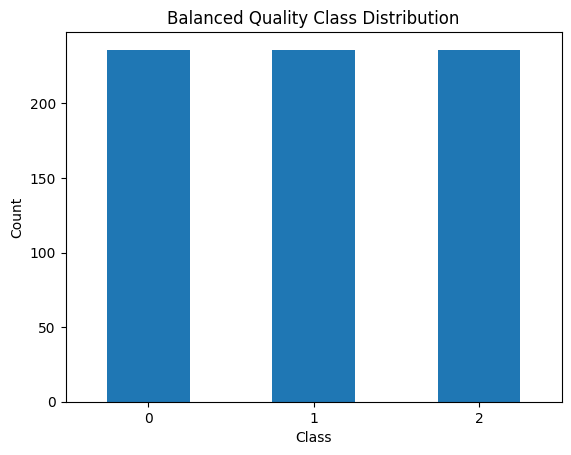

In [63]:
df_balanced["quality_class"].value_counts().sort_index().plot(kind="bar")
plt.title("Balanced Quality Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [62]:
X_bal = df_balanced.drop(columns=["quality", "quality_class"])
y_bal = df_balanced["quality_class"]

print("X_bal shape:", X_bal.shape)
print("y_bal shape:", y_bal.shape)

X_bal shape: (708, 12)
y_bal shape: (708,)


In [64]:
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal
)

print("X_train_b shape:", X_train_bal.shape)
print("X_test_b shape:", X_test_bal.shape)

X_train_b shape: (566, 12)
X_test_b shape: (142, 12)


In [66]:
# Scale the balanced data
scaler_bal = StandardScaler()
X_train_bal_scaled = scaler_bal.fit_transform(X_train_bal)
X_test_bal_scaled = scaler_bal.transform(X_test_bal)

models_balanced = {
    "SVM": SVC(),
    "RF": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(),
    "GB": GradientBoostingClassifier(random_state=42),
    "DT": DecisionTreeClassifier(random_state=42)
}

results_balanced = []

for name, model in models_balanced.items():
    # Using corrected variable names: y_train_bal, X_train_bal_scaled, etc.
    model.fit(X_train_bal_scaled, y_train_bal)
    preds = model.predict(X_test_bal_scaled)

    report = classification_report(y_test_bal, preds, output_dict=True)

    results_balanced.append([
        name,
        report["0"]["precision"], report["0"]["recall"], report["0"]["f1-score"],
        report["1"]["precision"], report["1"]["recall"], report["1"]["f1-score"],
        report["2"]["precision"], report["2"]["recall"], report["2"]["f1-score"],
        accuracy_score(y_test_bal, preds)
    ])

balanced_table = pd.DataFrame(
    results_balanced,
    columns=[
        "Model",
        "Class0_Precision", "Class0_Recall", "Class0_F1",
        "Class1_Precision", "Class1_Recall", "Class1_F1",
        "Class2_Precision", "Class2_Recall", "Class2_F1",
        "Accuracy"
    ]
)

print("Balanced Dataset Results")
balanced_table

Balanced Dataset Results


,Model,Class0_Precision,Class0_Recall,Class0_F1,Class1_Precision,Class1_Recall,Class1_F1,Class2_Precision,Class2_Recall,Class2_F1,Accuracy
0,SVM,0.750000,0.702128,0.725275,0.564103,0.468085,0.511628,0.677966,0.833333,0.747664,0.669014
1,RF,0.681818,0.638298,0.659341,0.450000,0.382979,0.413793,0.620690,0.750000,0.679245,0.591549
2,KNN,0.641509,0.723404,0.680000,0.540541,0.425532,0.476190,0.673077,0.729167,0.700000,0.626761
3,GB,0.794872,0.659574,0.720930,0.590909,0.553191,0.571429,0.694915,0.854167,0.766355,0.690141
4,DT,0.577778,0.553191,0.565217,0.372093,0.340426,0.355556,0.537037,0.604167,0.568627,0.500000


In [67]:
# transpose models
balanced_table_t = balanced_table.set_index("Model").T
balanced_table_t

Model,SVM,RF,KNN,GB,DT
Class0_Precision,0.750000,0.681818,0.641509,0.794872,0.577778
Class0_Recall,0.702128,0.638298,0.723404,0.659574,0.553191
Class0_F1,0.725275,0.659341,0.680000,0.720930,0.565217
Class1_Precision,0.564103,0.450000,0.540541,0.590909,0.372093
Class1_Recall,0.468085,0.382979,0.425532,0.553191,0.340426
Class1_F1,0.511628,0.413793,0.476190,0.571429,0.355556
Class2_Precision,0.677966,0.620690,0.673077,0.694915,0.537037
Class2_Recall,0.833333,0.750000,0.729167,0.854167,0.604167
Class2_F1,0.747664,0.679245,0.700000,0.766355,0.568627
Accuracy,0.669014,0.591549,0.626761,0.690141,0.500000


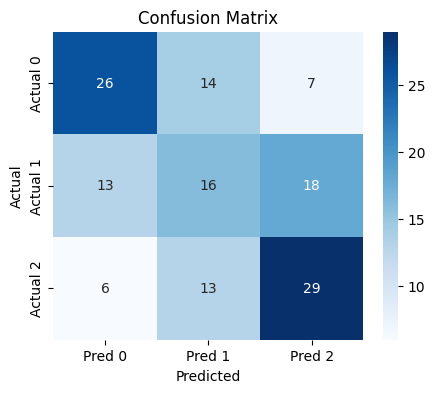

In [68]:
# confusion matrix for balanced
cm_bal = confusion_matrix(y_test_bal, preds)
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_bal,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred 0", "Pred 1", "Pred 2"],
    yticklabels=["Actual 0", "Actual 1", "Actual 2"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Balanced Dataset Results Interpretation

The balanced dataset changes the behavior of the models significantly compared to the unbalanced case. Since each class now has the same number of samples, the models are forced to learn all three classes more evenly instead of focusing on the majority class.

From the confusion matrix, performance is now more spread across all classes. For class 0, 26 samples were correctly predicted, with fewer being pushed into class 1 compared to the unbalanced case. This shows that the model is now much better at identifying bad wines.

For class 1, the model correctly predicted 16 samples, but there is still confusion with both class 0 and class 2. This explains why class 1 has the lowest performance across all metrics, with recall around 0.46 for SVM and even lower for some other models. The model struggles to clearly separate normal wines from the other two groups.

For class 2, performance improves noticeably. The model correctly predicts 29 samples, and recall is high across most models, reaching above 0.80 for some cases. This shows that good wines are now being identified more consistently than before.

Looking at the model comparison, Gradient Boosting performs the best overall with an accuracy of about 0.69, followed closely by SVM at around 0.67. Random Forest and KNN perform slightly worse, while Decision Tree has the lowest performance at about 0.50.

Unlike the unbalanced dataset, accuracy is lower overall, but the performance across classes is more consistent. Precision, recall, and F1 scores are now more balanced, which indicates that the models are learning each class more fairly instead of being biased toward a single dominant class.

This shows that balancing the dataset improves fairness across classes, even though it reduces overall accuracy. It also highlights that accuracy alone is not a reliable measure of model performance when class distributions are uneven.

### Using  SMOTE Tunning

In [82]:
from imblearn.over_sampling import SMOTE

In [83]:
X = df.drop(columns=["quality", "quality_class"])
y = df["quality_class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("training class counts before SMOTE")
print(y_train.value_counts().sort_index())

print("\ntest class counts")
print(y_test.value_counts().sort_index())

training class counts before SMOTE
quality_class
0     189
1    3260
2     807
Name: count, dtype: int64

test class counts
quality_class
0     47
1    815
2    202
Name: count, dtype: int64


In [84]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [85]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("training class counts after SMOTE")
print(pd.Series(y_train_smote).value_counts().sort_index())

training class counts after SMOTE
quality_class
0    3260
1    3260
2    3260
Name: count, dtype: int64


In [86]:
models_smote = {
    "SVM": SVC(),
    "RF": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier()
}

results_smote = []

for name, model in models_smote.items():
    model.fit(X_train_smote, y_train_smote)
    preds = model.predict(X_test_scaled)

    report = classification_report(y_test, preds, output_dict=True)

    results_smote.append([
        name,
        report["0"]["precision"], report["0"]["recall"], report["0"]["f1-score"],
        report["1"]["precision"], report["1"]["recall"], report["1"]["f1-score"],
        report["2"]["precision"], report["2"]["recall"], report["2"]["f1-score"],
        accuracy_score(y_test, preds)
    ])

smote_table = pd.DataFrame(
    results_smote,
    columns=[
        "Model",
        "Class0_Precision", "Class0_Recall", "Class0_F1",
        "Class1_Precision", "Class1_Recall", "Class1_F1",
        "Class2_Precision", "Class2_Recall", "Class2_F1",
        "Accuracy"
    ]
)

smote_table

,Model,Class0_Precision,Class0_Recall,Class0_F1,Class1_Precision,Class1_Recall,Class1_F1,Class2_Precision,Class2_Recall,Class2_F1,Accuracy
0,SVM,0.143713,0.510638,0.224299,0.882353,0.570552,0.692996,0.413514,0.757426,0.534965,0.603383
1,RF,0.230769,0.255319,0.242424,0.859155,0.823313,0.840852,0.541126,0.618812,0.577367,0.759398
2,KNN,0.132530,0.468085,0.206573,0.871212,0.564417,0.685034,0.391892,0.717822,0.506993,0.589286


In [88]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, classification_report

In [89]:
svm_pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("svm", SVC())
])

svm_params = {
    "smote__k_neighbors": [3, 5, 7],
    "svm__C": [1, 10, 50, 100],
    "svm__kernel": ["rbf"],
    "svm__gamma": ["scale", 0.01, 0.1, 1]
}

svm_grid = GridSearchCV(
    svm_pipeline,
    svm_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

svm_grid.fit(X_train_scaled, y_train)

best_svm = svm_grid.best_estimator_
preds_svm = best_svm.predict(X_test_scaled)

print("Best SVM params:", svm_grid.best_params_)
print("SVM Accuracy:", accuracy_score(y_test, preds_svm))
print(classification_report(y_test, preds_svm))

Best SVM params: {'smote__k_neighbors': 3, 'svm__C': 10, 'svm__gamma': 1, 'svm__kernel': 'rbf'}
SVM Accuracy: 0.7546992481203008
              precision    recall  f1-score   support

           0       0.19      0.13      0.15        47
           1       0.82      0.87      0.85       815
           2       0.52      0.42      0.46       202

    accuracy                           0.75      1064
   macro avg       0.51      0.47      0.49      1064
weighted avg       0.73      0.75      0.74      1064



In [92]:
rf_pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("rf", RandomForestClassifier(random_state=42))
])

rf_params = {
    "smote__k_neighbors": [3, 5],
    "rf__n_estimators": [50, 100, 150],
    "rf__max_depth": [None, 10, 20, 30],
    "rf__min_samples_split": [2, 5],
    "rf__min_samples_leaf": [1, 2],
    "rf__max_features": ["sqrt", "log2"]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

rf_grid.fit(X_train_scaled, y_train)

best_rf = rf_grid.best_estimator_
preds_rf = best_rf.predict(X_test_scaled)

print("Best RF params:", rf_grid.best_params_)
print("RF Accuracy:", accuracy_score(y_test, preds_rf))
print(classification_report(y_test, preds_rf))

Best RF params: {'rf__max_depth': 30, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2, 'rf__n_estimators': 150, 'smote__k_neighbors': 3}
RF Accuracy: 0.7631578947368421
              precision    recall  f1-score   support

           0       0.24      0.21      0.23        47
           1       0.85      0.84      0.85       815
           2       0.54      0.59      0.56       202

    accuracy                           0.76      1064
   macro avg       0.54      0.55      0.55      1064
weighted avg       0.77      0.76      0.76      1064



### SMOTE Results Interpretation (SVM and Random Forest)

After applying SMOTE and tuning the models, there was a small improvement in overall accuracy, but the results still show clear limitations across the classes.

For SVM, the accuracy reached about 0.75. The model performs very well on class 1, with a recall of 0.87 and strong F1 score. However, performance drops a lot for class 0 and class 2. Class 0 has very low recall at 0.13, meaning the model is still struggling to correctly identify low quality wines. Class 2 performs better than class 0, but recall is still only 0.42, which shows confusion between classes.

Random Forest performed slightly better with an accuracy of about 0.76. Similar to SVM, it handles class 1 very well with high recall and strong F1 score. There is some improvement for class 2 compared to SVM, with recall reaching 0.59. However, class 0 is still very weak, with recall at only 0.21. This shows that even after balancing with SMOTE, the model still struggles to learn patterns for the lowest quality wines.

Overall, SMOTE helped improve performance compared to downsampling by keeping more data and slightly improving minority class predictions. However, the models are still biased toward class 1, and there is still overlap between the classes that limits performance. This shows that the challenge is not only imbalance, but also how similar the wine quality groups are.

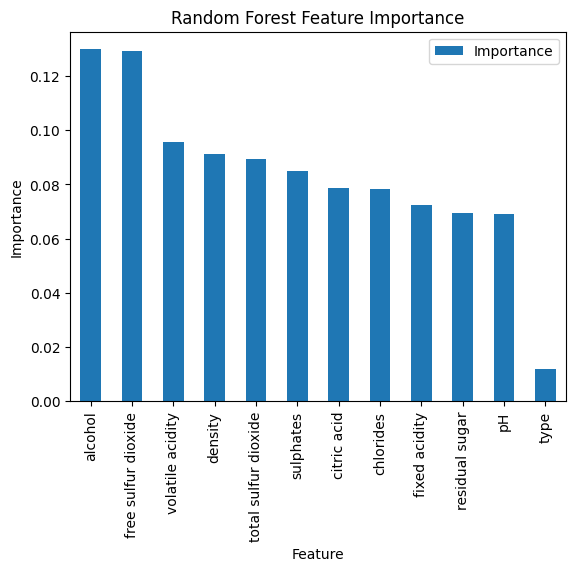

,Importance
alcohol,0.129837
free sulfur dioxide,0.129048
volatile acidity,0.095813
density,0.091257
total sulfur dioxide,0.089226
sulphates,0.084892
citric acid,0.078709
chlorides,0.078414
fixed acidity,0.072314
residual sugar,0.069569


In [101]:
# feature importance
feature_importances = pd.DataFrame(
    best_rf.named_steps["rf"].feature_importances_,
    index=X_train.columns,
    columns=["Importance"]).sort_values(by="Importance", ascending=False)


# plot in stacked bar chart
feature_importances.sort_values(by="Importance", ascending=False).plot(kind="bar")
plt.title("Random Forest Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.show()

feature_importances

### Reproducibility Considerations

One important issue in this project is the difficulty in reproducing the exact results reported in the paper. Even after applying SMOTE and tuning multiple parameters for SVM and Random Forest, the accuracy remained around 0.75 to 0.76, which is lower than what was reported.

A key reason for this is that the paper does not clearly provide all the tuning details. The exact parameter combinations, preprocessing steps, and how SMOTE was applied are not fully specified. Small differences in these steps can lead to noticeable changes in model performance.

Another factor is how the dataset is handled. Differences in train test splits, scaling methods, or how classes are grouped can all affect results. Without full transparency, it becomes difficult to exactly match the reported accuracy.

This highlights an important point in machine learning research. If methods are not clearly documented, it limits reproducibility. Even when the same models and techniques are used, the results may not match because critical details are missing.

### Ethical Implications

The results from this analysis connect closely to the ethical issues discussed in the project. Even after applying SMOTE, the models still perform much better on one class compared to others. This shows how models can still carry bias even when steps are taken to balance the data.

As discussed earlier, models tend to learn patterns directly from the data. If certain groups or classes are harder to learn or not clearly separated, the model may still favor the easier or more dominant patterns. In this case, the model continues to perform best on class 1 while struggling with class 0.

This becomes an ethical concern when models are used for decision making. If certain groups are consistently misclassified, the model may appear accurate overall but still produce unfair outcomes. This is similar to how bias in real world datasets can lead to unequal performance across different groups.

Another important point is that improving accuracy alone does not solve bias. Even though SMOTE improved performance slightly, it did not fully fix the imbalance in predictions. This shows that addressing bias requires more than just technical adjustments. It requires understanding the data, how it is structured, and how the model is learning from it.

Overall, these results show that fairness and performance need to be considered together. A model with high accuracy can still be problematic if it does not perform well across all groups.